In [1]:
import sympy
import numpy as np
import matplotlib.pyplot as plt
from sympy.functions import exp

In [2]:
x1,x2 = sympy.symbols('x1 x2')

In [3]:
f_x = x1 * exp(-(x1**2 + x2**2))
f_x

x1*exp(-x1**2 - x2**2)

In [4]:
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
grad_f

[-2*x1**2*exp(-x1**2 - x2**2) + exp(-x1**2 - x2**2),
 -2*x1*x2*exp(-x1**2 - x2**2)]

In [5]:
f_x_fcn = sympy.lambdify([x1,x2],f_x)

In [7]:
grad_fcn = sympy.lambdify([x1,x2],grad_f)

In [9]:
xx1,xx2 = np.meshgrid(np.linspace(-2,2,40),np.linspace(-2,2,40))

In [13]:
xx1_,xx2_ = np.meshgrid(np.linspace(-2,2,20),np.linspace(-2,2,20))
V = grad_fcn(xx1_,xx2_)

In [17]:
ff_x = f_x_fcn(xx1,xx2)

In [18]:
color_array = np.sqrt(V[0]**2 + V[1]**2)

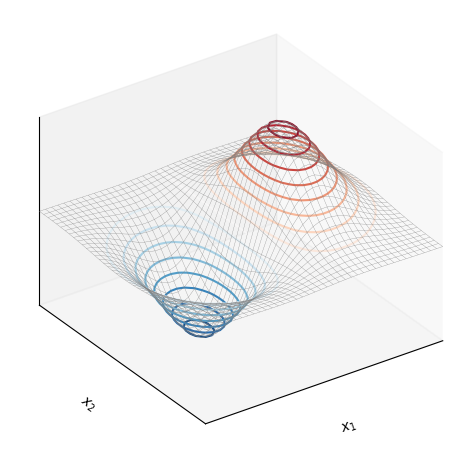

In [22]:
ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,
                  cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdBu_r')

ax.xaxis.set_ticks([])  # 去除 x 轴刻度
ax.yaxis.set_ticks([])  # 去除 y 轴刻度
ax.zaxis.set_ticks([])  # 去除 z 轴刻度
plt.xlim(-2, 2)  # 设置 x 轴范围
plt.ylim(-2, 2)  # 设置 y 轴范围
ax.set_proj_type('ortho')
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局以适应图形窗口


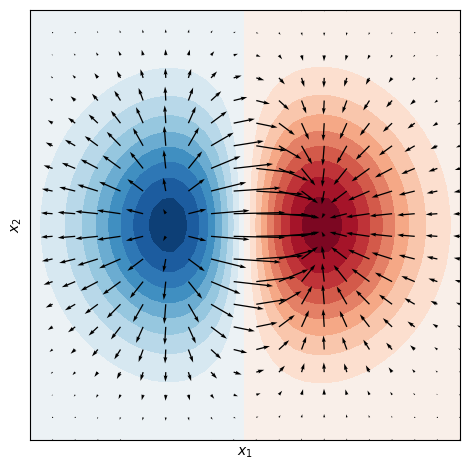

In [25]:
fig,ax = plt.subplots()

plt.contourf(xx1,xx2,ff_x,20,cmap = 'RdBu_r')

plt.quiver(xx1_,xx2_,V[0],V[1],
           angles = 'xy',scale_units = 'xy',
           edgecolor = 'none',facecolor = 'k')

ax.set_aspect('equal')  # 设置图形的纵横比
ax.xaxis.set_ticks([])  # 去除 x 轴刻度
ax.yaxis.set_ticks([])  # 去除 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局以适应图形窗口

In [28]:
import sympy
from sympy import Matrix,Transpose #Transpose用于矩阵转置
import numpy as np
from sympy.functions import exp
import matplotlib.pyplot as plt

In [51]:
def mesh_circ(c1,c2,r,num):
    theta = np.arange(0,2*np.pi + np.pi / num ,np.pi / num)
    r = np.arange(0,r,r / num) #/num是配置步长
    theta,r = np.meshgrid(theta,r)
    xx1 = np.cos(theta) * r + c1
    xx2 = np.sin(theta) * r + c2

    return xx1,xx2

In [52]:
x1,x2,p1,p2 = sympy.symbols('x1 x2 p1 p2')

In [53]:
f_x = -4 * x1 **2 - 4*x2 **2
f_x

-4*x1**2 - 4*x2**2

In [54]:
f_p = -4 * p1 **2 - 4*p2 **2
f_p

-4*p1**2 - 4*p2**2

In [55]:
grad_f = [sympy.diff(f_p,var) for var in (p1,p2)]
grad_f

[-8*p1, -8*p2]

In [56]:
f_x_fcn = sympy.lambdify([x1,x2],f_x)

In [57]:
t_x = Matrix(grad_f).T * Matrix([[x1 - p1],[x2 - p2]]) + Matrix([f_p])
print(t_x) #构建平面表达式

Matrix([[-4*p1**2 - 8*p1*(-p1 + x1) - 4*p2**2 - 8*p2*(-p2 + x2)]])


In [58]:
t_x_fcn = sympy.lambdify([x1,x2,p1,p2],t_x)

In [59]:
grad_fcn = sympy.lambdify([x1,x2],grad_f)

In [60]:
xx1,xx2 = mesh_circ(0,0,3,20)

In [61]:
p1,p2 = -1.5,0
py = f_x_fcn(p1,p2)

In [70]:
xx1_,xx2_ = np.meshgrid(np.linspace(p1 - 1,p1 +1 ,10),
                        np.linspace(p2 - 1,p2 +1,10))

In [71]:
ff_x = f_x_fcn(xx1,xx2)

In [72]:
tt_x = t_x_fcn(xx1_,xx2_,p1,p2)

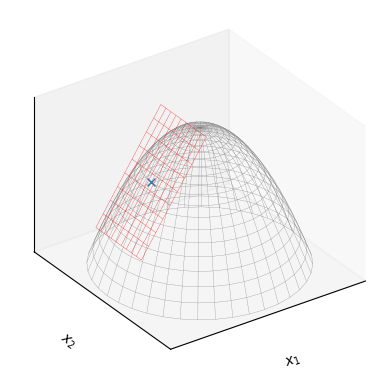

In [74]:
fig = plt.figure()
ax = plt.axes(projection = '3d')

ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,
                  cstride = 1,color= '0.5',
                  linewidth = 0.2)

ax.plot_wireframe(xx1_,xx2_,np.squeeze(tt_x),rstride = 1, #squeeze是去掉没有意义的维度
                  cstride = 1,color = [1,0,0],
                  linewidth = 0.2)
ax.plot(p1,p2,py,'x')

# 去除坐标轴刻度
ax.xaxis.set_ticks([])  # 去除 x 轴刻度
ax.yaxis.set_ticks([])  # 去除 y 轴刻度
ax.zaxis.set_ticks([])  # 去除 z 轴刻度
plt.xlim(-3, 3)  # 设置 x 轴范围
plt.ylim(-3, 3)  # 设置 y 轴范围
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
ax.set_proj_type('ortho')